<a href="https://colab.research.google.com/github/Juci-Dev/Challenge-Alura/blob/main/TelecomX_parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# importando a biblioteca pandas para leitura do arquivo

import pandas as pd

In [4]:
# lendo o dataframe

url = 'https://raw.githubusercontent.com/Juci-Dev/Challenge-Desafio2/refs/heads/main/Challenge-Desafio2_dados_tratados.csv'
df = pd.read_csv(url)
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [5]:

# entendendo as colunas

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [6]:

# entendendo os valores nulos

df.isna().sum()

,0
customerID,0
Churn,224
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [7]:
# retirando a coluna Customer ID

df = df.drop('customerID',axis=1)

In [8]:
# verificando se foi retirado

df.columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total'],
      dtype='object')

In [11]:
# verificando a correlação entre as colunas Charges.Monthly e Charges.Total

df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
correlacao = df['Charges.Monthly'].corr(df['Charges.Total'])
print(f"Correlação entre Charges.Monthly e Charges.Total: {correlacao}")

Correlação entre Charges.Monthly e Charges.Total: 0.6521086225230759


In [13]:
# verificando a correlação entre as colunas Charges Monthly e Charges Total

correlacao_2 = df['Charges.Monthly'].corr(df['Charges.Total'])
print(f"Correlação entre Charges.Monthly e Charges.Total: {correlacao_2}")

Correlação entre Charges.Monthly e Charges.Total: 0.6521086225230759


In [16]:

df.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [18]:
# ajustando as colunas do Internet Service

df['InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [19]:
# copiando o df para um df limpo

df_limpo = df.copy()

In [21]:
# substituindo os valores de Internet Service No em todas as colunas internet

colunas_ajuste = ['OnlineSecurity', 'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

for column in colunas_ajuste:
    df_limpo[column] = df_limpo[column].replace('No internet service', 'No')

In [23]:
# verificando se deu certo

df_limpo['OnlineSecurity'].unique()

array(['No', 'Yes'], dtype=object)

Encoding

In [24]:
# entendendo quais variáveis iremos transformar a partir de valores únicos

df_limpo.nunique()

,0
Churn,2
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,2


In [25]:

# entendendo quais são as variáveis categóricas a partir do dtype

df_limpo.dtypes

,0
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [26]:
# atribuindo as variáveis categóricas a uma variável

variaveis_categoricas = df_limpo.select_dtypes(include='object').columns
print(variaveis_categoricas)

Index(['Churn', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [27]:
# criando dataframe encoded

df_encoded = pd.get_dummies(df_limpo, columns=variaveis_categoricas, drop_first=True)

In [28]:
# testando o novo df

df_encoded.head()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Churn_Yes,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,65.6,593.30,False,False,True,True,True,False,...,False,True,True,False,True,False,True,False,False,True
1,0,9,59.9,542.40,False,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,True,True,False,False,True,False,...,True,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,True,True,True,False,True,False,...,True,False,True,True,False,False,True,False,True,False
4,1,3,83.9,267.40,True,False,True,False,True,False,...,False,True,True,False,False,False,True,False,False,True


In [29]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7267 non-null   int64  
 1   tenure                                 7267 non-null   int64  
 2   Charges.Monthly                        7267 non-null   float64
 3   Charges.Total                          7256 non-null   float64
 4   Churn_Yes                              7267 non-null   bool   
 5   gender_Male                            7267 non-null   bool   
 6   Partner_Yes                            7267 non-null   bool   
 7   Dependents_Yes                         7267 non-null   bool   
 8   PhoneService_Yes                       7267 non-null   bool   
 9   MultipleLines_No phone service         7267 non-null   bool   
 10  MultipleLines_Yes                      7267 non-null   bool   
 11  Inte

In [34]:
# verificando os valores nulos da coluna account.Charges.Total

print(df_encoded['Charges.Total'].isnull().sum())

11


In [36]:
# retirando os valores nulos da coluna Charges.Total

df_encoded = df_encoded.dropna(subset=['Charges.Total'])

In [38]:
df_encoded['Charges.Total'].isnull().sum()

np.int64(0)

Verificação da Proporção de Evasão

In [39]:
# calculando a proporção de clientes Churn_Yes

df_encoded['Churn_Yes'].value_counts(normalize=True)

,proportion
Churn_Yes,
False,0.74242
True,0.25758


Correlação e Seleção de Variáveis


In [40]:
corr = df_encoded.corr()

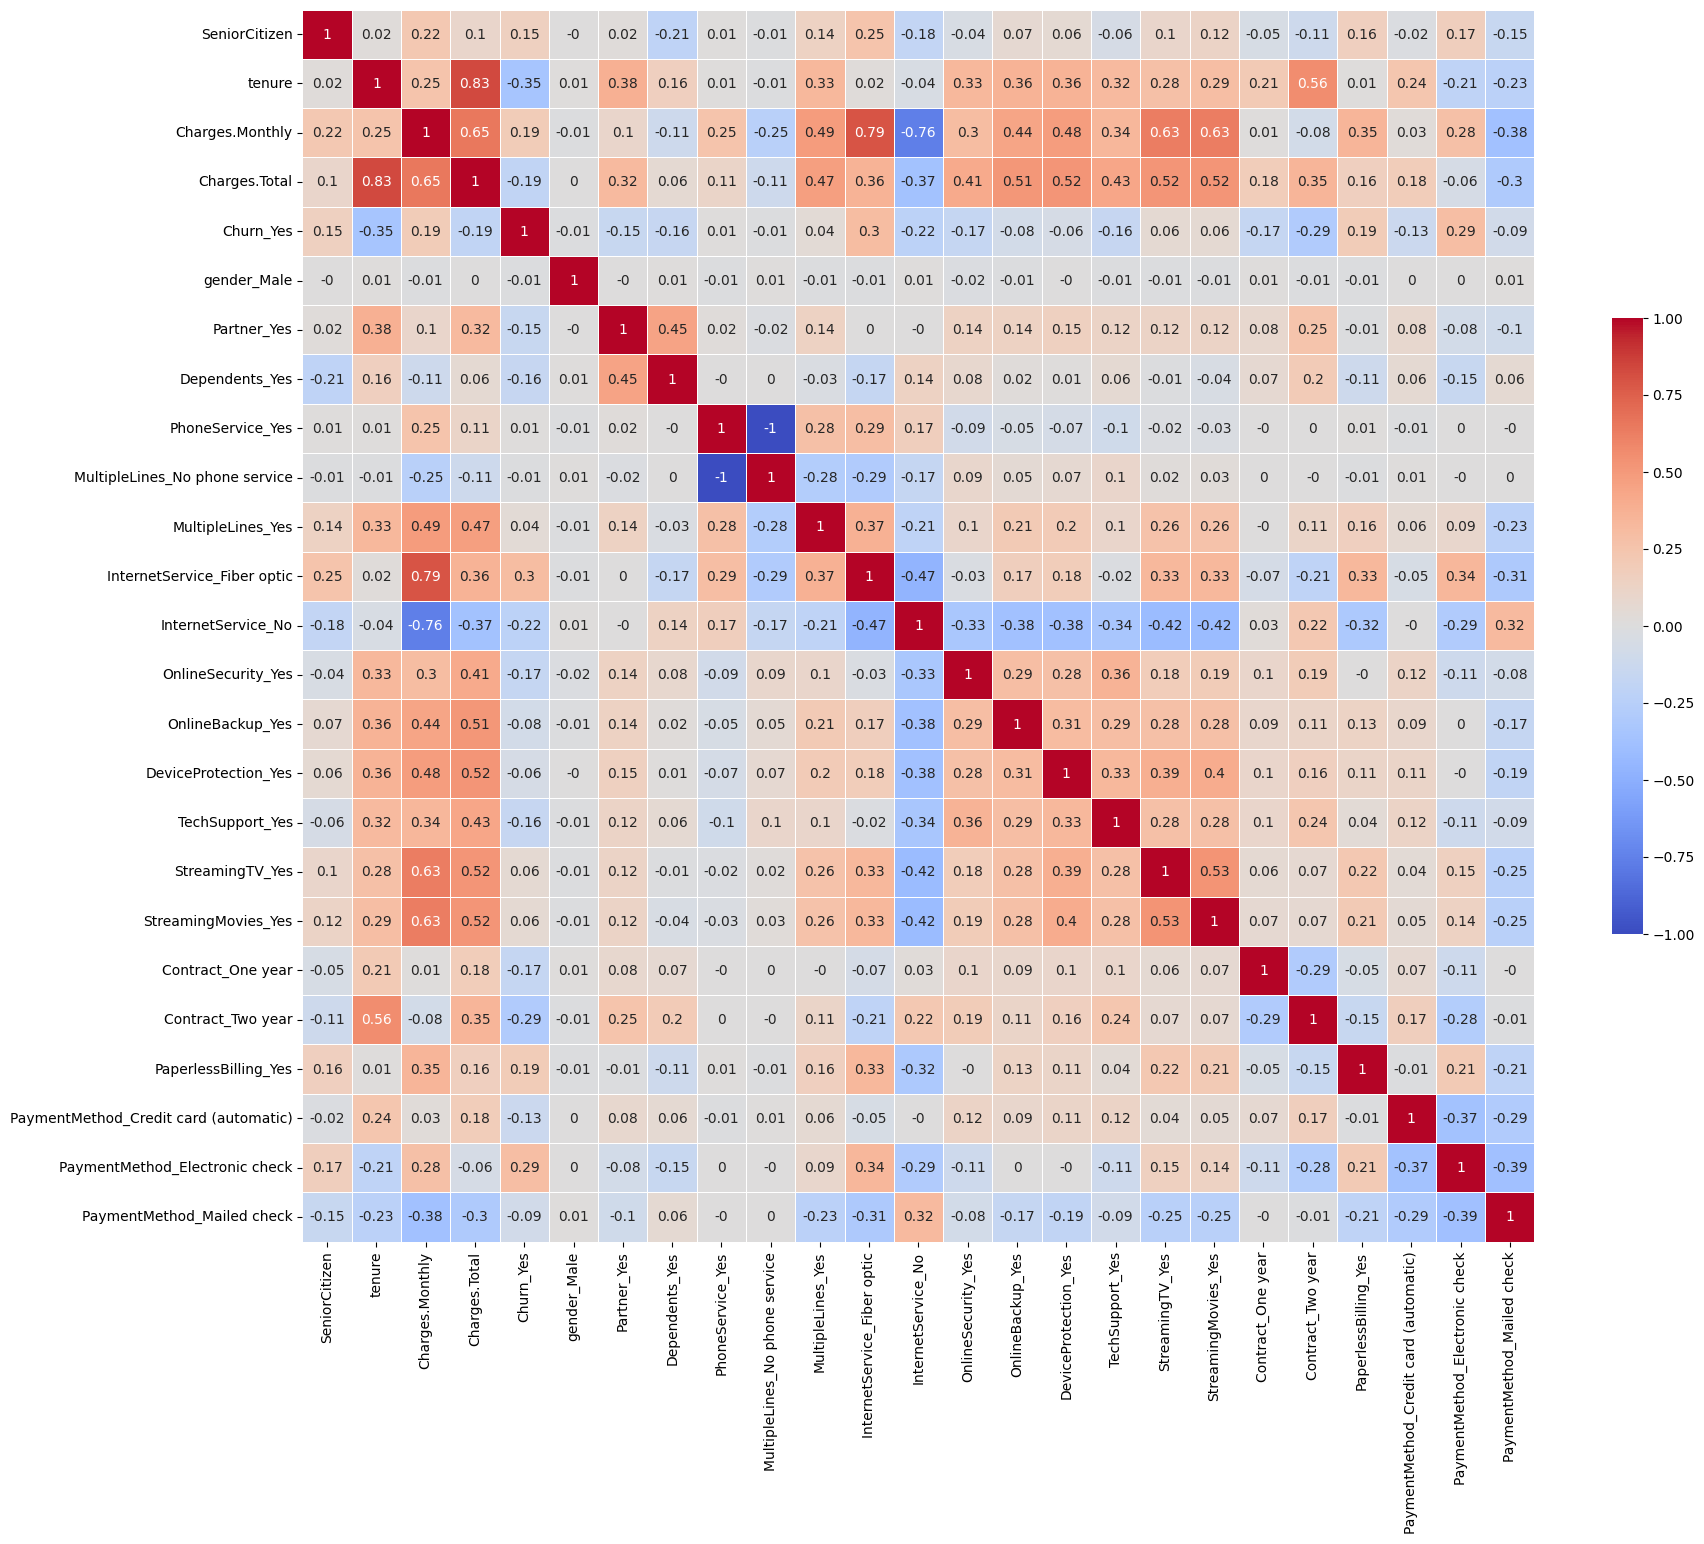

In [41]:
# analisando correlações em um gráfico de heatmap

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 16))
ax = sns.heatmap(np.round(corr,2), vmax=1, vmin=-1, center=0, square=True, linewidths=.5, annot=True, cmap='coolwarm', cbar_kws={'shrink':.5})
plt.show()


In [42]:
# filtrando as correlações mais relevantes a partir da correlação com a variável Churn_Yes

corr_churn = corr['Churn_Yes'].drop('Churn_Yes')

In [43]:
# filtrando apenas correlações com valor absoluto maior que 0.2

corr_churn_filtrado = corr_churn[abs(corr_churn) > 0.2]

In [44]:
# ordenando por valor absoluto da correlação decrescente

corr_churn_ordenado = corr_churn_filtrado.reindex(corr_churn_filtrado.abs().sort_values(ascending=False).index)

In [45]:
corr_churn_ordenado

,Churn_Yes
tenure,-0.345799
InternetService_Fiber optic,0.300416
Contract_Two year,-0.294467
PaymentMethod_Electronic check,0.294181
InternetService_No,-0.223755


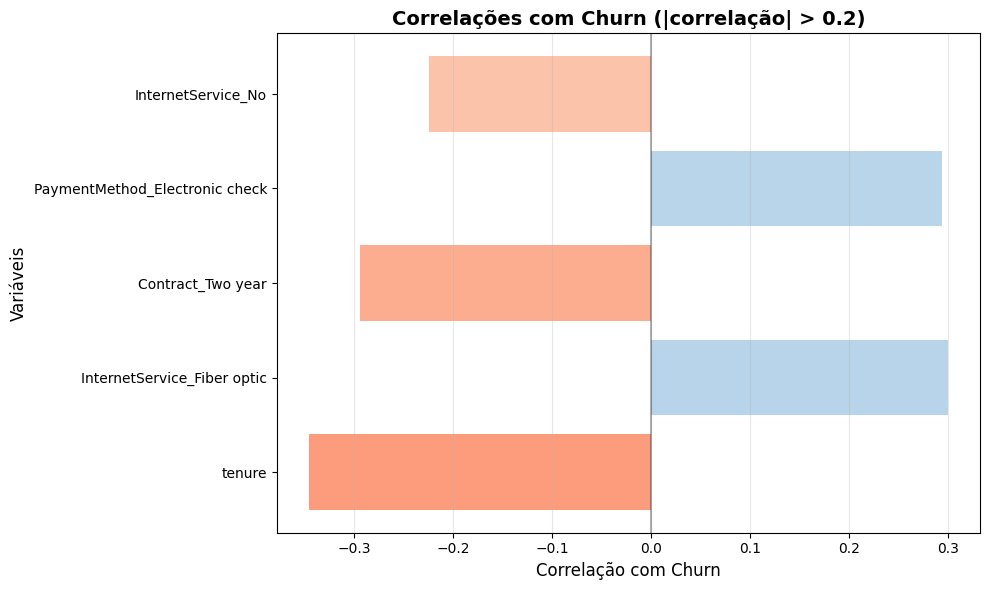

In [46]:
# configurando estilo do gráfico

plt.style.use('default')
sns.set_palette("husl")

# criando paleta de cores
colors = [
    plt.cm.Blues(abs(val)) if val > 0 else plt.cm.Reds(abs(val))
    for val in corr_churn_ordenado.values
]

# plotando o gráfico para avaliar a correlação das variáveis mais relevantes

plt.figure(figsize=(10, 6))
bars = plt.barh(range(len(corr_churn_ordenado)), corr_churn_ordenado.values, color=colors)

# personalizando  o gráfico
plt.yticks(range(len(corr_churn_ordenado)), corr_churn_ordenado.index, fontsize=10)
plt.xlabel('Correlação com Churn', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.title('Correlações com Churn (|correlação| > 0.2)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)

# ajustando layout e mostrar o gráfico
plt.tight_layout()
plt.grid(axis='x', alpha=0.3)
plt.show()

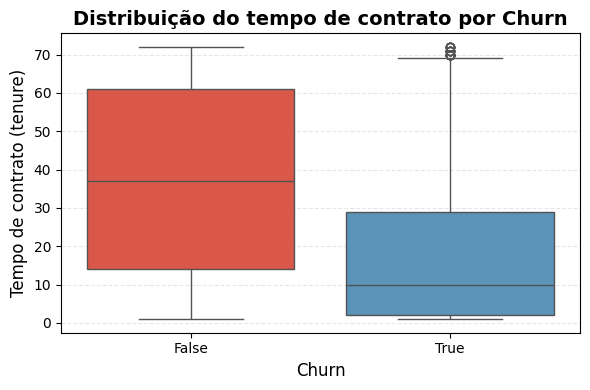

In [48]:
# análise de tempo de contrato x evasão (churn) em boxplot

plt.figure(figsize=(6, 4))
colors = {
    False: plt.cm.Reds(0.6),
    True: plt.cm.Blues(0.6)
}

sns.boxplot(
    x='Churn_Yes',
    y='tenure',
    data=df_encoded,
    palette=colors,
    hue='Churn_Yes',
    legend=False
)

plt.xlabel("Churn", fontsize=12)
plt.ylabel("Tempo de contrato (tenure)", fontsize=12)
plt.title("Distribuição do tempo de contrato por Churn", fontsize=14, fontweight="bold")
plt.grid(axis='y', linestyle="--", alpha=0.3)
plt.tight_layout()

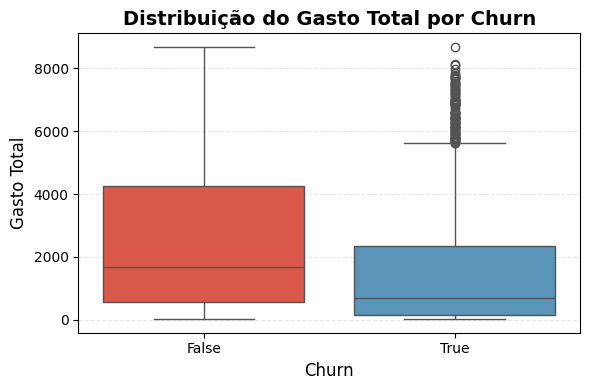

In [50]:
# análise de gasto total x evasão em um gráfico de boxplot


plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_encoded,
    x="Churn_Yes",
    y="Charges.Total",
    palette={False: plt.cm.Reds(0.6),
    True: plt.cm.Blues(0.6)},
    hue='Churn_Yes',
    legend=False
)

plt.xlabel("Churn", fontsize=12)
plt.ylabel("Gasto Total", fontsize=12)
plt.title("Distribuição do Gasto Total por Churn", fontsize=14, fontweight="bold")
plt.grid(axis='y', linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

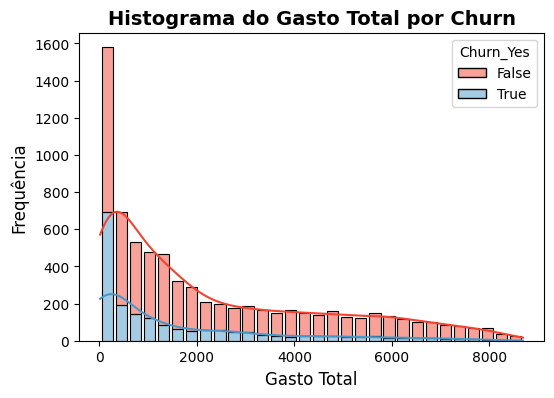

In [52]:
# análise de gasto total por churn em um histograma

plt.figure(figsize=(6, 4))

sns.histplot(
    data=df_encoded,
    x="Charges.Total",
    palette=colors,
    hue="Churn_Yes",
    multiple="stack",
    shrink=0.8,
    kde=True,
    bins=30,
    alpha=0.5
)
plt.xlabel("Gasto Total", fontsize=12)
plt.ylabel("Frequência", fontsize=12)
plt.title("Histograma do Gasto Total por Churn", fontsize=14, fontweight="bold")
plt.show()

Extra: Análise de Multicolinearidade


In [53]:
# importando as bibliotecas para análise de multicolinearidade

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [54]:
# definindo as variáveis para o teste

X = df_encoded.drop('Churn_Yes', axis=1)
X_const = add_constant(X)

In [55]:
# calculando o VIF

X_const = X_const.astype(float)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

display(vif_data.sort_values(by='VIF', ascending=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
8,PhoneService_Yes,inf
9,MultipleLines_No phone service,inf
3,Charges.Monthly,872.488197
11,InternetService_Fiber optic,149.253496
12,InternetService_No,105.055970
18,StreamingMovies_Yes,24.249121
17,StreamingTV_Yes,24.146092
4,Charges.Total,10.832700
2,tenure,7.580478
10,MultipleLines_Yes,7.317710


In [57]:
# filtrando o dataframe para retirar as variáveis com VIF muito alta ou infinita

cols_to_drop = ['PhoneService_Yes','MultipleLines_No phone service','InternetService_No']

X_filtered = X_const.copy()
X_filtered.drop(columns=cols_to_drop, inplace=True)
X_filtered = X_filtered.astype(float)

vif_data_filtered = pd.DataFrame()
vif_data_filtered["Feature"] = X_filtered.columns
vif_data_filtered["VIF"] = [variance_inflation_factor(X_filtered.values, i) for i in range(X_filtered.shape[1])]

display(vif_data_filtered.sort_values(by='VIF', ascending=False))

,Feature,VIF
0,const,36.396029
3,Charges.Monthly,18.205892
4,Charges.Total,10.726482
2,tenure,7.547207
9,InternetService_Fiber optic,7.015878
17,Contract_Two year,2.532487
14,StreamingTV_Yes,2.184554
15,StreamingMovies_Yes,2.181385
20,PaymentMethod_Electronic check,1.971148
21,PaymentMethod_Mailed check,1.849397


In [59]:
# retirando o Charges.Total

X_filtered = X_filtered.drop('Charges.Total', axis=1)

In [60]:
# recalculando a vif

X_filtered = X_filtered.astype(float)

vif_data_filtered = pd.DataFrame()
vif_data_filtered["Feature"] = X_filtered.columns
vif_data_filtered["VIF"] = [variance_inflation_factor(X_filtered.values, i) for i in range(X_filtered.shape[1])]

display(vif_data_filtered.sort_values(by='VIF', ascending=False))

,Feature,VIF
0,const,29.483644
3,Charges.Monthly,17.314276
8,InternetService_Fiber optic,6.954312
2,tenure,2.834080
16,Contract_Two year,2.521098
13,StreamingTV_Yes,2.161979
14,StreamingMovies_Yes,2.157500
19,PaymentMethod_Electronic check,1.968115
20,PaymentMethod_Mailed check,1.826027
12,TechSupport_Yes,1.708863


Separação de Dados

In [61]:
# importando as bibliotecas necessárias

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

In [62]:
# definindo as variáveis

X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']


In [63]:
# separando as variáveis entre treino e teste

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Criação de modelos
Logistic Regression

In [65]:
# importando a biblioteca do modelo

from sklearn.linear_model import LogisticRegression

In [66]:
# normalizando com Standard Scaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [67]:
# balanceando os dados com SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [68]:
# rodando o modelo de Logistic Regression

modelo_lr = LogisticRegression(random_state=42)
modelo_lr.fit(X_train_resampled, y_train_resampled)

# realizando as previsões
y_pred_lr = modelo_lr.predict(X_test_scaled)
y_prob_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]

In [69]:
# avaliando o modelo

print('Modelo de Regressão Logística')
print('Acurácia:', accuracy_score(y_test, y_pred_lr))
print('ROC AUC:', roc_auc_score(y_test, y_prob_lr))
print('Matriz de Confusão:')
print(confusion_matrix(y_test, y_pred_lr))
print('Relatório de Classificação:')
print(classification_report(y_test, y_pred_lr))



Modelo de Regressão Logística
Acurácia: 0.7606798346348186
ROC AUC: 0.8460344196184325
Matriz de Confusão:
[[1205  411]
 [ 110  451]]
Relatório de Classificação:
              precision    recall  f1-score   support

       False       0.92      0.75      0.82      1616
        True       0.52      0.80      0.63       561

    accuracy                           0.76      2177
   macro avg       0.72      0.77      0.73      2177
weighted avg       0.82      0.76      0.77      2177



XGBoost

In [70]:
# importando bibliotecas

import xgboost as xgb
from xgboost import XGBClassifier

In [71]:
# rodando o modelo XGBoost

modelo_xgb = XGBClassifier(random_state=42, eval_metric='logloss')
modelo_xgb.fit(X_train_resampled, y_train_resampled)

# realizando as previsões

y_pred_xgb = modelo_xgb.predict(X_test_scaled)
y_prob_xgb = modelo_xgb.predict_proba(X_test_scaled)[:, 1]

In [72]:
# avaliando o modelo

print('Modelo de XGBoost')
print('Acurácia:', accuracy_score(y_test, y_pred_xgb))
print('ROC AUC:', roc_auc_score(y_test, y_prob_xgb))
print('Matriz de Confusão:')
print(confusion_matrix(y_test, y_pred_xgb))
print('Relatório de Classificação:')
print(classification_report(y_test, y_pred_xgb))

Modelo de XGBoost
Acurácia: 0.7758383096003675
ROC AUC: 0.8253726107904908
Matriz de Confusão:
[[1361  255]
 [ 233  328]]
Relatório de Classificação:
              precision    recall  f1-score   support

       False       0.85      0.84      0.85      1616
        True       0.56      0.58      0.57       561

    accuracy                           0.78      2177
   macro avg       0.71      0.71      0.71      2177
weighted avg       0.78      0.78      0.78      2177



Comparação Matriz de Confusão

In [73]:
# importando o Display Matrix para comparar os modelos

from sklearn.metrics import ConfusionMatrixDisplay

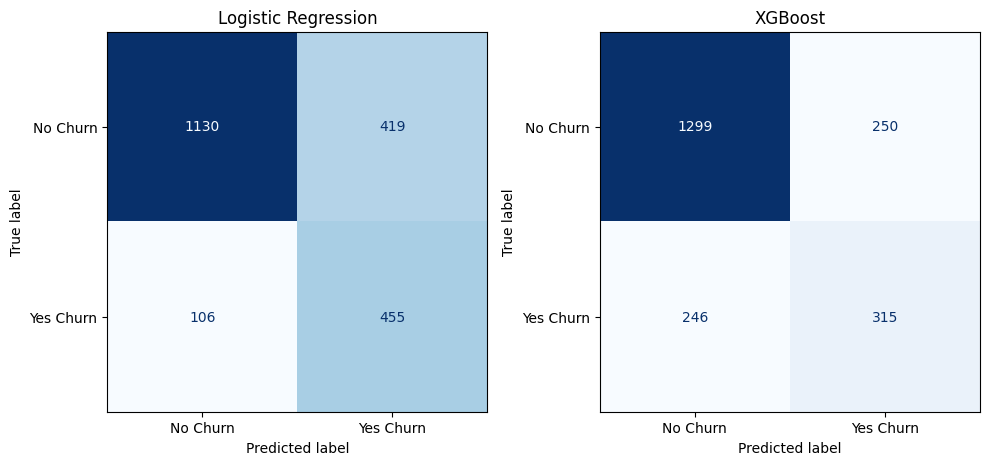

In [74]:
# Matrizes de confusão
cm_logreg = np.array([[1130, 419],
                      [106, 455]])

cm_xgb = np.array([[1299, 250],
                   [246, 315]])

# Nomes das classes
classes = ["No Churn", "Yes Churn"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Logistic Regression
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, display_labels=classes)
disp1.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Logistic Regression")

# XGBoost
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=classes)
disp2.plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("XGBoost")

plt.tight_layout()
plt.show()

📊 Resumo da Análise de Modelos de Churn

Logistic Regression – "Detector Sensível"

Captura 81% dos churns (455/561)

Muitos falsos positivos (419)

Melhor ROC AUC (84,5%)

XGBoost – "Detector Conservador"

Menos falsos positivos (250)

Mas perde muitos churns reais (só 44% capturados)

ROC AUC menor (80,9%)

🚀 Conclusão

Logistic Regression é o melhor modelo

Recall muito superior (81% vs 56%)

Para churn, vale mais "errar para mais" e não perder clientes.

Exemplo: em 1000 churns, Logistic salvaria +250 clientes em relação ao XGBoost.

🔑 Estratégia

Usar Logistic Regression quando: custo de retenção é baixo e perder cliente é caro.

Usar XGBoost quando: retenção é cara e recursos são limitados.

🔮 Próximos Passos

Testar balanceamento avançado (SMOTEENN, class weights).

Criar novas variáveis (tempo até cancelamento, gasto atual/histórico).

Ajustar hiperparâmetros e validar com cross-validation.

Considerar ensembles (Logistic + XGBoost).

Ajustar threshold para otimizar recall/precisão.

Análise de Importância das Variáveis


In [75]:

# extraindo o coef do modelo

coef = modelo_lr.coef_[0]

# juntando com os nomes das variáveis X_train
feature_importance_log = pd.DataFrame({
    'Variável': X_train.columns,
    'Coeficiente': coef
})

# Ordenando pela importância absoluta
feature_importance_log['Importância_Absoluta'] = np.abs(feature_importance_log['Coeficiente'])
feature_importance_log = feature_importance_log.sort_values(by='Importância_Absoluta', ascending=False)

print(feature_importance_log[['Variável','Coeficiente']])

                                 Variável  Coeficiente
1                                  tenure    -1.624305
3                           Charges.Total     0.932662
2                         Charges.Monthly    -0.874829
10            InternetService_Fiber optic     0.665047
11                     InternetService_No    -0.635139
19                      Contract_Two year    -0.507665
18                      Contract_One year    -0.353541
17                    StreamingMovies_Yes     0.264176
20                   PaperlessBilling_Yes     0.247830
16                        StreamingTV_Yes     0.238487
9                       MultipleLines_Yes     0.208523
22         PaymentMethod_Electronic check     0.162581
15                        TechSupport_Yes    -0.155222
12                     OnlineSecurity_Yes    -0.121980
6                          Dependents_Yes    -0.099519
0                           SeniorCitizen     0.079416
14                   DeviceProtection_Yes     0.048668
13        

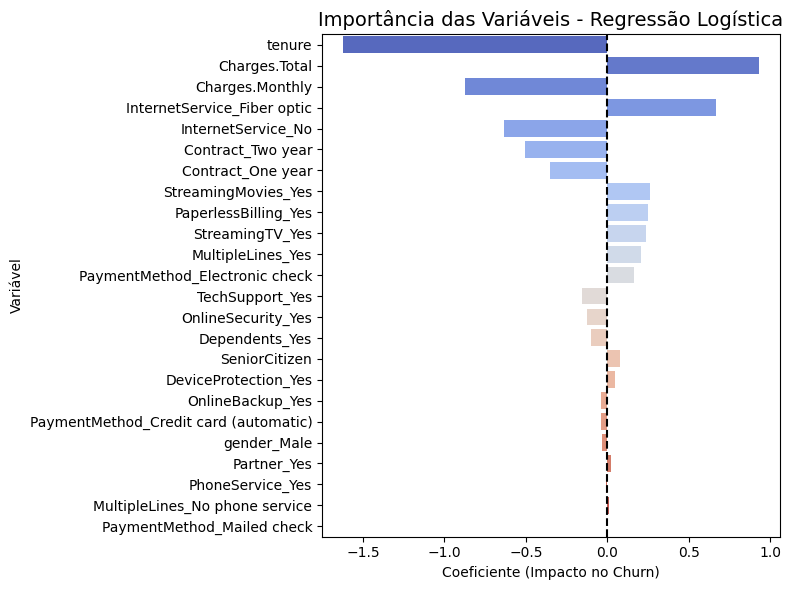

In [76]:
# visualizando em gráfico

# Plotando os coeficientes ordenados
plt.figure(figsize=(8,6))
sns.barplot(
    data=feature_importance_log,
    x='Coeficiente',
    y='Variável',
    palette='coolwarm',
    hue='Variável',
    legend=False
)

plt.title("Importância das Variáveis - Regressão Logística", fontsize=14)
plt.xlabel("Coeficiente (Impacto no Churn)")
plt.ylabel("Variável")
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

XGBoost


In [77]:
# utilizando a função feature_importance do XGBoost

feature_importance_xgb = pd.DataFrame({
    'Variável': X_train.columns,
    'Importância': modelo_xgb.feature_importances_
})

# Ordenando pela importância
feature_importance_xgb = feature_importance_xgb.sort_values(by='Importância', ascending=False)

print(feature_importance_xgb)

                                 Variável  Importância
19                      Contract_Two year     0.305039
10            InternetService_Fiber optic     0.132587
18                      Contract_One year     0.104878
11                     InternetService_No     0.078970
22         PaymentMethod_Electronic check     0.044370
17                    StreamingMovies_Yes     0.037910
20                   PaperlessBilling_Yes     0.032783
9                       MultipleLines_Yes     0.025331
12                     OnlineSecurity_Yes     0.023860
15                        TechSupport_Yes     0.023565
16                        StreamingTV_Yes     0.019907
7                        PhoneService_Yes     0.019819
1                                  tenure     0.018483
5                             Partner_Yes     0.018446
6                          Dependents_Yes     0.017699
4                             gender_Male     0.017695
13                       OnlineBackup_Yes     0.017246
14        

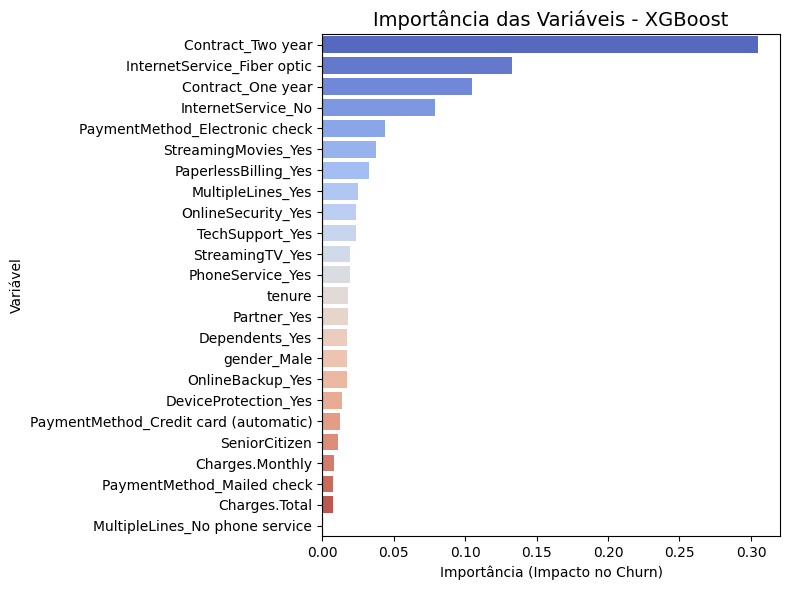

In [78]:
# visualizando em gráfico

# Plotando os coeficientes ordenados
plt.figure(figsize=(8,6))
sns.barplot(
    data=feature_importance_xgb,
    x='Importância',
    y='Variável',
    palette='coolwarm',
    hue='Variável',
    legend=False
)

plt.title("Importância das Variáveis - XGBoost", fontsize=14)
plt.xlabel("Importância (Impacto no Churn)")
plt.ylabel("Variável")
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# Conclusão da Análise de Evasão de Clientes
Principais Fatores Identificados

Tempo de permanência: clientes com contratos mais longos apresentam menor propensão ao churn.

Gastos totais: clientes com maiores despesas demonstram maior risco de evasão.

Tipo de internet: planos de fibra ótica estão associados a maior taxa de cancelamento.

Modelo contratual: contratos de um ou dois anos reduzem significativamente a probabilidade de saída.

Serviços adicionais: adesão a serviços como streaming, suporte técnico e cobrança eletrônica contribui para maior retenção.

Estratégias de Retenção Propostas

Estímulo a contratos de longo prazo

Ofertas e benefícios que incentivem a migração de planos mensais para anuais ou bianuais.

Melhoria da experiência com a internet de fibra ótica

Monitoramento constante da satisfação e reforço em qualidade e suporte.

Gestão de clientes de alto valor

Atendimento diferenciado, pacotes exclusivos e benefícios que reduzam o risco de evasão.

Promoção de serviços adicionais

Ampliação do portfólio de serviços que aumentem o engajamento e dificultem a migração para concorrentes.

Considerações Finais

Ambos os modelos confirmam que contratos mais longos, tempo de permanência e perfil de uso da internet são determinantes no comportamento de evasão.
Assim, as estratégias de retenção devem priorizar a fidelização por meio de contratos estendidos, monitoramento da qualidade do serviço e atenção especial a clientes de maior valor, promovendo maior estabilidade na base de clientes.